In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Разминка 1. Медицинский тест и априорная вероятность

Есть медицинский тест с точностью $99\%$.

Это значит:

- если человек болен, тест покажет болезнь в $99$ случаях из $100$;
- если человек здоров, тест покажет здоровье в $99$ случаях из $100$.

Заболевание очень редкое: реально болеет $1$ человек из $1\,000\,000$.

**Вопрос**

Человек сдаёт тест, который показывает положительный результат. Какова вероятность, что он действительно болен?


**Решение**

Обозначим:

- $D$ — человек болен;
- $\neg D$ — человек здоров;
- $+$ — тест положительный.

Распространённость болезни:

$$\mathbb{P}(D) = \frac{1}{1\,000\,000} = 0.000001.$$

Это и есть **априорная вероятность** болезни: вероятность быть больным до получения результата теста.

Чувствительность теста:

$$\mathbb{P}(+ \mid D) = 0.99.$$

Специфичность теста:

$$\mathbb{P}(- \mid \neg D) = 0.99.$$

Значит, вероятность ложноположительного результата:

$$\mathbb{P}(+ \mid \neg D) = 0.01.$$

Вероятность быть здоровым:

$$\mathbb{P}(\neg D) = 1 - P(D) = 0.999999.$$


Нас интересует вероятность действительно быть больным при условии, что тест положительный $\mathbb{P}(D \mid +)$. Это уже **апостериорная вероятность**: вероятность после того, как мы получили новую информацию — положительный результат теста.

In [ ]:
p_d = 1 / 1000000
p_nd = 1 - p_d

p_plus_if_d = 0.99

p_minus_if_nd = 0.99
p_plus_if_nd = 1 - p_minus_if_nd

Используем формулу Байеса:

$$
P(D \mid +) =
\frac{P(+ \mid D)P(D)}
{P(+ \mid D)P(D) + P(+ \mid \neg D)P(\neg D)}.
$$

Подставим значения:

$$
P(D \mid +) =
\frac{0.99 \cdot 0.000001}
{0.99 \cdot 0.000001 + 0.01 \cdot 0.999999}.
$$


Сначала посчитаем числитель:

$$0.99 \cdot 0.000001 = 0.00000099.$$

Теперь знаменатель:

$$0.00000099 + 0.01 \cdot 0.999999 = 0.01000098.$$

Тогда:

$$\mathbb{P}(D \mid +) = \frac{0.00000099}{0.01000098};$$

$$\mathbb{P}(D \mid +) \approx 0.00009899.$$

В процентах:

$$0.00009899 \cdot 100\% \approx 0.009899\%.$$

То есть примерно $0.01\%$.

Иначе говоря, это около **$1$ шанса из $10 000$**.


In [ ]:
num = p_plus_if_d * p_d
denom = p_plus_if_d * p_d + p_plus_if_nd * p_nd

p_d_if_plus = num / denom

print(num)
print(denom)
print(p_d_if_plus *100)

9.9e-07
0.010000980000000008
0.009899029895070277


**Интуитивное объяснение**

Представим $1000000$ человек.

Из них:

- $1$ человек действительно болен;
- $999 999$ человек здоровы.

Среди больных:

- тест найдёт болезнь с вероятностью $99\%$;
- значит, получим примерно $0.99$ истинно положительных результата.

Среди здоровых:

- тест ошибочно покажет болезнь у $1\%$;
- значит, получим примерно

$$
999 999 \cdot 0.01 = 9 999.99
$$

ложноположительных результатов.

Всего положительных результатов будет примерно:

$$
0.99 + 9999.99 = 10000.98.
$$

Из них действительно больных примерно $0.99$.

Поэтому доля действительно больных среди всех людей с положительным тестом

$$
\frac{0.99}{10000.98} \approx 0.00009899,
$$

или примерно $0.01\%$.


# Разминка 2. Пространство элементарных исходов для игр с монеткой и кубиком

Бросается монетка.

Если она выпала гербом, то её бросают ещё раз, иначе бросают кубик.

Необходимо:

 - Описать пространство элементарных исходов
 - Создать (с помощью кода) таблицу, которая сопоставит исходы и их вероятности
 - Нарисовать функцию вероятности данной случайной величины
  - Посчитать ожидаемый выигрыш по правилам:

    - Герб стоит $100$ рублей
    - Решка отнимает $100$ рублей
    - Грань кубика даёт своё значение, умноженное на $10$



**Решение**


Сначала бросают монетку.

Есть два сценария.

**Сценарий 1. На первом броске монетки выпал герб**

Тогда монетку бросают ещё раз. Второй бросок монетки может дать одно из двух значений:

$$Г, Р$$

Получаем исходы:

$$(Г,Г),(Г,Р)$$

**Сценарий 2. На первом броске монетки выпала решка**

Тогда бросают кубик. Бросок кубика может дать одно из шести значений:

$$1,2,3,4,5,6$$

Получаем исходы:

$$(Р,1),(Р,2),(Р,3),(Р,4),(Р,5),(Р,6)$$

Итак, пространство элементарных исходов:

$$\Omega_1=\{(Г,Г),(Г,Р),(Р,1),(Р,2),(Р,3),(Р,4),(Р,5),(Р,6)\}$$

**Вывод**

Пространство элементарных исходов первой игры состоит из $8$ исходов: $2$ исходов со вторым броском монетки и $6$ исходов с броском кубика.


**Вероятность исходов**

Монетка и кубик правильные.

Значит,

$$\mathbb P(Г)=\mathbb P(Р)=\frac12$$

и

$$\mathbb P(1)=\mathbb P(2)=\ldots=\mathbb P(6)=\frac16$$

Тогда:

$$\mathbb P((Г,Г))=\mathbb P(Г)\cdot\mathbb P(Г)=\frac12\cdot\frac12=\frac14$$

$$\mathbb P((Г,Р))=\mathbb P(Г)\cdot\mathbb P(Р)=\frac12\cdot\frac12=\frac14$$

Для каждого $k\in\{1,2,3,4,5,6\}$:

$$\mathbb P((Р,k))=\mathbb P(Р)\cdot\mathbb P(k)=\frac12\cdot\frac16=\frac1{12}$$

Проверим нормировку для первой игры:

$$\frac14+\frac14+6\cdot\frac1{12}=\frac12+\frac12=1$$


In [ ]:
outcomes = ["(Г, Г)", "(Г, Р)"] + [f"(Р, {i})" for i in range(1, 7)]
probs = [1/4, 1/4] + [1/12] * 6

df = pd.DataFrame({
    "Исход": outcomes,
    "Вероятность": probs
})

In [ ]:
outcomes

['(Г, Г)',
 '(Г, Р)',
 '(Р, 1)',
 '(Р, 2)',
 '(Р, 3)',
 '(Р, 4)',
 '(Р, 5)',
 '(Р, 6)']

In [ ]:
probs

[0.25,
 0.25,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333,
 0.08333333333333333]

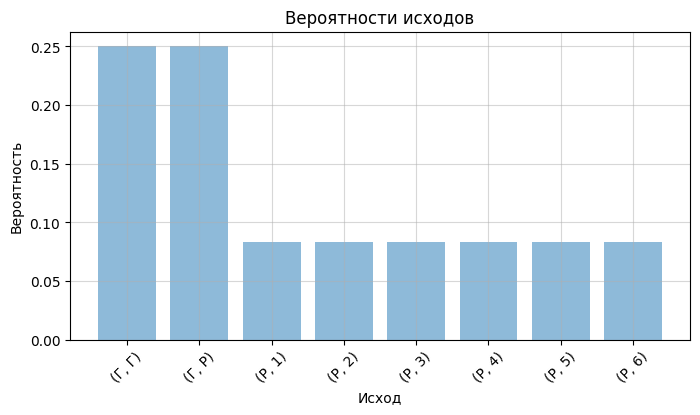

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(df["Исход"], df["Вероятность"], alpha=.5)
plt.xlabel("Исход")
plt.ylabel("Вероятность")
plt.title("Вероятности исходов")
plt.grid(alpha=.5)
plt.xticks(rotation=45)
plt.show()

**Перейдём к ожидаемому выигрышу**

In [ ]:
wins = [100 + 100, 100 - 100] + [-100 + i * 10 for i in range(1, 7)]

df["Выигрыш"] = wins
df["Вероятность * Выигрыш"] = df["Вероятность"] * df["Выигрыш"]

expected_win = df["Вероятность * Выигрыш"].sum()

df

,Исход,Вероятность,Выигрыш,Вероятность * Выигрыш
0,"(Г, Г)",0.250000,200,50.000000
1,"(Г, Р)",0.250000,0,0.000000
2,"(Р, 1)",0.083333,-90,-7.500000
3,"(Р, 2)",0.083333,-80,-6.666667
4,"(Р, 3)",0.083333,-70,-5.833333
5,"(Р, 4)",0.083333,-60,-5.000000
6,"(Р, 5)",0.083333,-50,-4.166667
7,"(Р, 6)",0.083333,-40,-3.333333


In [ ]:
print(expected_win)

17.500000000000004


# Разминка 3. Поведение заемщиков и вариационный ряд

Сегодня мы побудем в роли аналитиков банка.

Мы будем работать с таблицей **LOAN** (Кредиты), чтобы понять, какие суммы чаще всего берут наши клиенты.

**Структура таблицы LOAN:**
* `loan_id` — уникальный номер кредита (PK)
* `account_id` — номер счета клиента (FK)
* `amount` — сумма кредита
* `duration` — срок кредита
* `payments` — ежемесячный платеж
* `status` — статус кредита (выплачен, просрочен и т.д.)


### Пункт 1. Загрузка данных

In [ ]:
# Загружаем таблицу с правильным разделителем ';'
df_loan = pd.read_csv('loan.csv', sep=';')

# Показываем первые 5 строк, чтобы проверить колонки
print("Первые 5 строк таблицы LOAN:")
print(df_loan.head())

Первые 5 строк таблицы LOAN:
   loan_id  account_id    date  amount  duration  payments status
0     5314        1787  930705   96396        12    8033.0      B
1     5316        1801  930711  165960        36    4610.0      A
2     6863        9188  930728  127080        60    2118.0      A
3     5325        1843  930803  105804        36    2939.0      A
4     7240       11013  930906  274740        60    4579.0      A


Берем колонку 'amount' для нашей работы


In [ ]:
loan_amounts = df_loan['amount'].tolist()

print(loan_amounts[:5])
print(type(loan_amounts))

[96396, 165960, 127080, 105804, 274740]
<class 'list'>


In [ ]:
n_duration = len(loan_amounts)
print(len(loan_amounts))

682


### Пункт 2. Переход к частотному ряду по длительности кредита

Извлекаем данные о сроках кредитов из нашей таблицы и превращаем их в упорядоченную выборку (вариационный ряд).

In [ ]:
duration_series = sorted(df_loan['duration'].tolist())

print(f"Минимальный срок кредита: {duration_series[0]} мес.")
print(f"Максимальный срок кредита: {duration_series[-1]} мес.")

Минимальный срок кредита: 12 мес.
Максимальный срок кредита: 60 мес.


Рассчитаем, сколько раз встречается каждый конкретный срок (в абсолютном и относительном выражении).

In [ ]:
duration_counts = pd.Series(duration_series).value_counts().sort_index()
duration_rel_counts = pd.Series(duration_series).value_counts(normalize=True).sort_index()

print(duration_counts)
print(duration_rel_counts)

12    131
24    138
36    130
48    138
60    145
Name: count, dtype: int64
12    0.192082
24    0.202346
36    0.190616
48    0.202346
60    0.212610
Name: proportion, dtype: float64


Определим накопленные характеристики с помощью метода *cumsum*.

In [ ]:
duration_cum_counts = duration_counts.cumsum()
duration_cum_rel_counts = duration_rel_counts.cumsum()

Соберём всё в одну таблицу частотного ряда

In [ ]:
duration_table = pd.DataFrame({
    'Срок кредита (мес.)': duration_counts.index,
    'Частота (n_i)': duration_counts.values,
    'Отн. частота (w_i)': duration_rel_counts.values,
    'Накопл. частота (S_i)': duration_cum_counts.values,
    'Накопл. отн. частота (F_i)': duration_cum_rel_counts.values
})

In [ ]:
duration_table

,Срок кредита (мес.),Частота (n_i),Отн. частота (w_i),Накопл. частота (S_i),Накопл. отн. частота (F_i)
0,12,131,0.192082,131,0.192082
1,24,138,0.202346,269,0.394428
2,36,130,0.190616,399,0.585044
3,48,138,0.202346,537,0.787390
4,60,145,0.212610,682,1.000000


### Пункт 3. Расчёт количества бинов и вариационный ряд для размеров кредита

Определим порядковые статистики и размах выборки.

In [ ]:
variational_series = sorted(loan_amounts)

n = len(variational_series)
print(f"Общее число наблюдений (размер выборки n): {n}")

min_stat = variational_series[0]   # X_(1)
max_stat = variational_series[-1]  # X_(n)

print(f"Минимальная порядковая статистика X_(1) (самый маленький кредит): {min_stat}")
print(f"Максимальная порядковая статистика X_({n}) (самый большой кредит): {max_stat}")

sample_range = max_stat - min_stat
print(f"Размах выборки (R = X_({n}) - X_(1)): {sample_range}")

Общее число наблюдений (размер выборки n): 682
Минимальная порядковая статистика X_(1) (самый маленький кредит): 4980
Максимальная порядковая статистика X_(682) (самый большой кредит): 590820
Размах выборки (R = X_(682) - X_(1)): 585840


**Формула Стерджесса**

In [ ]:
import math

k_sturges = math.ceil(1 + math.log2(n))
h_sturges = sample_range / k_sturges

print(k_sturges)
print(h_sturges)

11
53258.181818181816


**Формула Фридмана-Дьякони**

Рассчитаем IQR.

In [ ]:
q25 = np.percentile(variational_series, 25)
q75 = np.percentile(variational_series, 75)
iqr = q75 - q25

In [ ]:
h_fd = (2 * iqr) / (n ** (1/3))
k_fd = math.ceil(sample_range / h_fd)

print(k_fd)
print(h_fd)

18
32701.102102220284


### Пункт 4. Создание таблицы

Берем количество интервалов по Стерджессу из прошлого шага. Настраиваем границы интервалов от минимума до максимума

In [ ]:
bins = np.linspace(min_stat, max_stat, k_sturges + 1)

# Создаем списки для сбора информации по каждому интервалу
interval_labels = []
midpoints = []
counts = []

# Проходим циклом по каждому интервалу и считаем его параметры
for i in range(k_sturges):
    # Определение границ интервалов
    left_edge = bins[i]
    right_edge = bins[i+1]

    # Формируем красивую подпись границ интервала
    # Включаем правую границу для самого последнего интервала
    if i == k_sturges - 1:
        label = f"[{left_edge:.1f} : {right_edge:.1f}]"
        # Считаем частоту интервала (сколько кредитов попало внутрь)
        count = sum((np.array(variational_series) >= left_edge) & (np.array(variational_series) <= right_edge))
    else:
        label = f"[{left_edge:.1f} : {right_edge:.1f})"
        count = sum((np.array(variational_series) >= left_edge) & (np.array(variational_series) < right_edge))

    # Определение срединного значения интервала
    midpoint = (left_edge + right_edge) / 2

    interval_labels.append(label)
    midpoints.append(midpoint)
    counts.append(count)


In [ ]:
# Переводим всё в массивы для удобства расчетов накопленных величин
counts = np.array(counts)
total_n = len(variational_series)

# Определение относительной частоты интервала
rel_counts = counts / total_n

# Определение накопленной частоты
cum_counts = np.cumsum(counts)

# Определение накопленной относительной частоты
cum_rel_counts = np.cumsum(rel_counts)

# Собираем все расчеты в одну итоговую таблицу для студентов
interval_table = pd.DataFrame({
    'boundaries': interval_labels,
    'x_mid': midpoints,
    'n_i': counts,
    'w_i': rel_counts,
    'S_i': cum_counts,
    'F_i': cum_rel_counts
})

In [ ]:
interval_table

,boundaries,x_mid,n_i,w_i,S_i,F_i
0,[4980.0 : 58238.2),31609.090909,147,0.215543,147,0.215543
1,[58238.2 : 111496.4),84867.272727,185,0.271261,332,0.486804
2,[111496.4 : 164754.5),138125.454545,98,0.143695,430,0.630499
3,[164754.5 : 218012.7),191383.636364,91,0.133431,521,0.763930
4,[218012.7 : 271270.9),244641.818182,55,0.080645,576,0.844575
5,[271270.9 : 324529.1),297900.000000,46,0.067449,622,0.912023
6,[324529.1 : 377787.3),351158.181818,21,0.030792,643,0.942815
7,[377787.3 : 431045.5),404416.363636,22,0.032258,665,0.975073
8,[431045.5 : 484303.6),457674.545455,11,0.016129,676,0.991202
9,[484303.6 : 537561.8),510932.727273,2,0.002933,678,0.994135


## Пункт 5. Визуализации

**Визуализации, построенные на сырой выборке**

**Гистограмма**

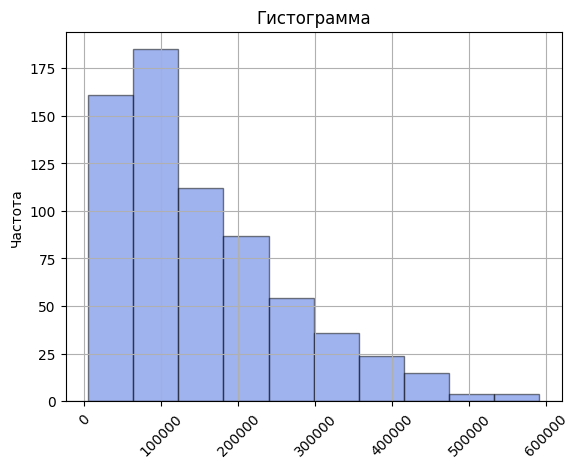

In [ ]:
plt.hist(loan_amounts, color='royalblue', edgecolor='black', alpha=0.5)
plt.title(f'Гистограмма')
plt.ylabel('Частота')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Боксплот**

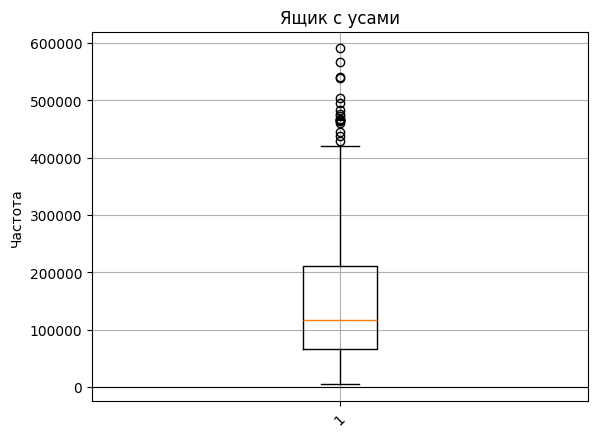

In [ ]:
plt.boxplot(loan_amounts)
plt.title(f'Ящик с усами')
plt.ylabel('Частота')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45)
plt.grid()
plt.show()

**Визуализации, построенные на вариационном ряде**

**Полигон частот**

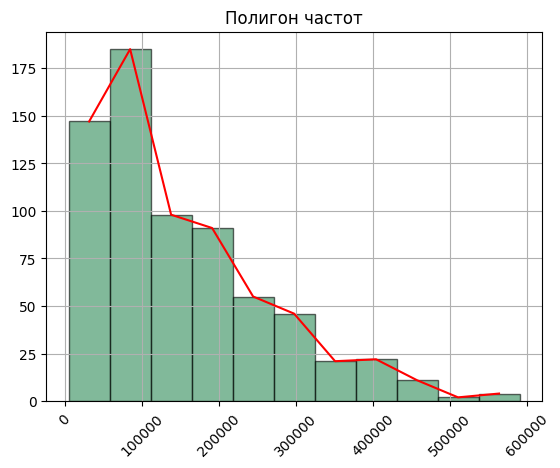

In [ ]:
fig, ax = plt.subplots()

ax.hist(loan_amounts, bins=bins, alpha=0.6, color='seagreen', edgecolor='black')
ax.plot(interval_table['x_mid'], interval_table['n_i'], color='red')
plt.xticks(rotation=45)
plt.title('Полигон частот')
plt.grid()
plt.show()

**Кумулята**

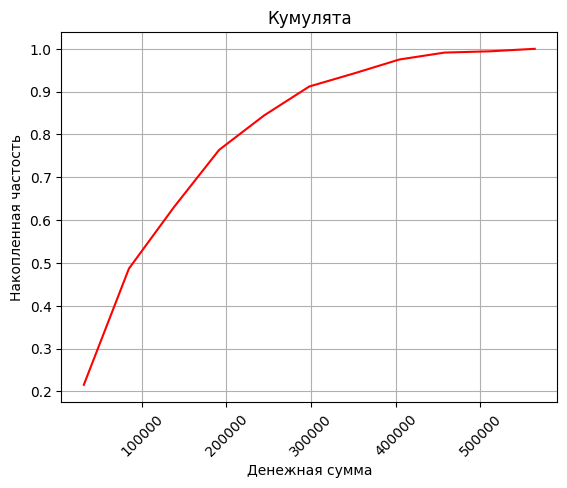

In [ ]:
plt.plot(interval_table['x_mid'], interval_table['F_i'], color='red')
plt.xticks(rotation=45)
plt.title('Кумулята')
plt.xlabel('Денежная сумма')
plt.ylabel('Накопленная частость')
plt.grid()
plt.show()

**Огива**

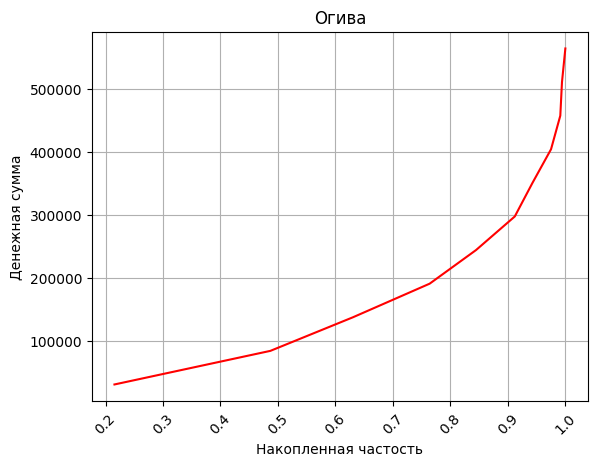

In [ ]:
plt.plot(interval_table['F_i'], interval_table['x_mid'], color='red')
plt.xticks(rotation=45)
plt.title('Огива')
plt.xlabel('Накопленная частость')
plt.ylabel('Денежная сумма')
plt.grid()
plt.show()

# Посмотрим на распределения

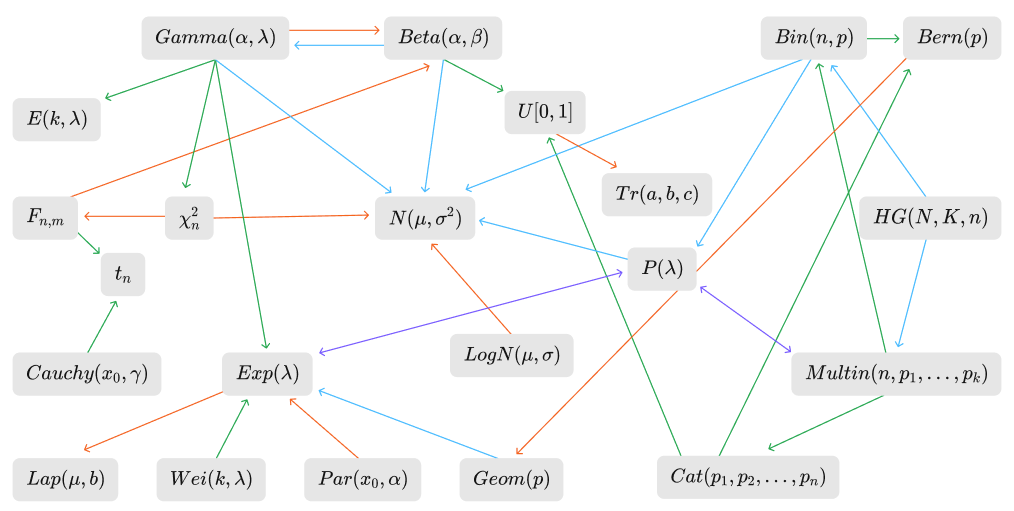

# Задача 1. Порассуждаем о фудтехе

Рассмотрим сферу доставки продуктов из физических магазинов.  

**Вопросы**

- В каких заказах средняя оценка удовлетворённости заказом будет ниже: в маленьких или в больших — и почему?

- Какое распределение можно использовать для ответа на этот вопрос?

- Какие предпосылки о клиентской функции полезности необходимо сделать?

**Решение**


Если в заказе много товаров, то выше вероятность, что хотя бы один товар соберут неправильно: заменят не тем аналогом, не найдут позицию, привезут товар плохого качества или ошибутся с количеством.

Пусть в заказе $n$ товаров, а вероятность ошибки по каждому товару равна $p$. Тогда число ошибок можно описывать биномиальным распределением:

$$
X\sim Bin(n,p)
$$

Вероятность того, что хотя бы один товар собран неправильно:

$$
\mathbb{P}(X\ge1)=1-\mathbb{P}(X=0)=1-(1-p)^n
$$

При фиксированном $p$ эта вероятность растёт с увеличением $n$. Поэтому в больших заказах чаще возникает хотя бы одна ошибка, которая может испортить впечатление клиента от всего заказа.

Чтобы связать это с оценкой удовлетворённости, полезно предположить, что клиентская функция полезности чувствительна к ошибкам: каждая ошибка снижает удовлетворённость, а иногда даже одна ошибка может резко ухудшить оценку всего заказа. Например, если клиент особенно ждал один важный товар, то неверная сборка именно этой позиции может сильно повлиять на итоговую оценку.

# Задача 2. Банковский сектор

В стране Х банковский сектор представлен тремя секторами:

- потребительский (44 банка),
- промышленный (32 банка),
- ипотечный (32 банка).

1. Вероятность дефолта банка из **потребительского** сектора составляет 12%. **Потребительский** сектор «испытает дефолт», если из 44 банков останется строго меньше 36.

2. Вероятность дефолта банка из **промышленного** сектора составляет 8%. **Промышленный** сектор «испытает дефолт», если из 32 банков останется строго меньше 27.

3. Вероятность дефолта банка из **ипотечного** сектора составляет 10%. **Ипотечный** сектор «испытает дефолт», если из 32 банков останется строго меньше 26.

Банковская система страны Х **выдержит кризис**, если в рамках этого кризиса осталось хотя бы два банковских сегмента из 3.

Рассчитай вероятность того, что банковская система страны Х выдержит кризис.

**Решение**


## **Шаг 1**

Рассчитаем и запишем в переменные пороговые значения дефолта для каждого банковского сегмента.

In [ ]:
n_cust = 44
p_cust = .12
k_cust = 36 # Порог для банков, которые должны остаться
thr_cust = 1 - k_cust / n_cust

cnt_def_cust = round(n_cust * p_cust)

print("Граница дефолта потреб. банков =", thr_cust)
print("Допустимое кол-во потреб. банков с дефолтом =", n_cust - k_cust)
print("Ожидаемое кол-во дефолтных потреб. банков =", cnt_def_cust)

Граница дефолта потреб. банков = 0.18181818181818177
Допустимое кол-во потреб. банков с дефолтом = 8
Ожидаемое кол-во дефолтных потреб. банков = 5


In [ ]:
n_ind = 32
p_ind = .08
k_ind = 27
thr_ind = 1 - k_ind / n_ind

cnt_def_ind = round(n_ind * p_ind)

print("Граница дефолта промышл. банков =", thr_ind)
print("Допустимое кол-во промышл. банков с дефолтом =", n_ind - k_ind)
print("Ожидаемое кол-во дефолтных промышл. банков =", cnt_def_ind)

Граница дефолта промышл. банков = 0.15625
Допустимое кол-во промышл. банков с дефолтом = 5
Ожидаемое кол-во дефолтных промышл. банков = 3


In [ ]:
n_mort = 32
p_mort = .1
k_mort = 26
thr_mort = 1 - k_mort / n_mort

cnt_def_mort = round(n_mort * p_mort)

print("Граница дефолта ипот. банков =", thr_mort)
print("Допустимое кол-во ипот. банков с дефолтом =", n_mort - k_mort)
print("Ожидаемое кол-во дефолтных ипот. банков =", cnt_def_mort)

Граница дефолта ипот. банков = 0.1875
Допустимое кол-во ипот. банков с дефолтом = 6
Ожидаемое кол-во дефолтных ипот. банков = 3


## **Шаг 2**

Рассчитаем вероятность дефолта каждого сегмента с помощью биномиального распределения.

In [ ]:
x_cust = np.arange(0, n_cust+1)
x_ind = np.arange(0, n_ind+1)
x_mort = np.arange(0, n_mort+1)

In [ ]:
from scipy.stats import binom

pmf_cust = binom.pmf(k=x_cust, n=n_cust, p=p_cust)
pmf_ind = binom.pmf(k=x_ind, n=n_ind, p = p_ind)
pmf_mort = binom.pmf(k=x_mort, n=n_mort, p=p_mort)

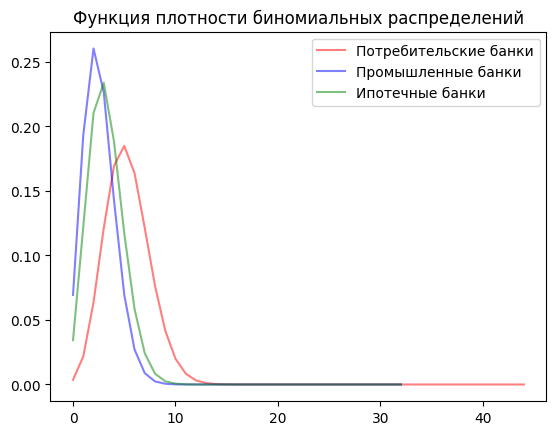

In [ ]:
plt.plot(x_cust, pmf_cust, color='red',   alpha=.5, label='Потребительские банки')
plt.plot(x_ind, pmf_ind,  color='blue',  alpha=.5, label='Промышленные банки')
plt.plot(x_mort, pmf_mort, color='green', alpha=.5, label='Ипотечные банки')
plt.title("Функция плотности биномиальных распределений")
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Вероятности для каждого сектора, что в нём будет допустимое кол-во банков с дефолтом
p_ndef_cust = binom.cdf(k=n_cust-k_cust, n=n_cust, p=p_cust)
p_ndef_ind  = binom.cdf(k=n_ind-k_ind,   n=n_ind,  p=p_ind )
p_ndef_mort = binom.cdf(k=n_mort-k_mort, n=n_mort, p=p_mort)

p_def_cust = 1 - p_ndef_cust
p_def_ind  = 1 - p_ndef_ind
p_def_mort = 1 - p_ndef_mort

print("Вероятность дефолта потребительского сектора =", p_def_cust)
print("Вероятность дефолта промышленного сектора =", p_def_ind)
print("Вероятность дефолта ипотечного сектора =", p_def_mort)

Вероятность дефолта потребительского сектора = 0.07462444050339123
Вероятность дефолта промышленного сектора = 0.039030013154306875
Вероятность дефолта ипотечного сектора = 0.035848867118464356


## **Шаг 3**

Рассчитаем вероятность дефолта всей страны Х.

In [ ]:
p_country_dies  = p_def_cust * p_def_ind * p_def_mort # Вероятность всех секторов уйти в дефолт
p_cust_ind_d = p_def_cust * p_def_ind * p_ndef_mort # Вероятность, что останется только ипотечный
p_cust_mort_d = p_def_cust * p_def_mort * p_ndef_ind # Вероятность, что останется только промышленный
p_ind_mort_d = p_def_ind * p_def_mort * p_ndef_cust # Вероятность, что останется только потребительский

negative_scenario = (p_country_dies + p_cust_ind_d + p_cust_mort_d + p_ind_mort_d)
p_country_lives = 1 - negative_scenario

print("Вероятность дефолта страны =", negative_scenario)
print("Вероятность выживания страны =", p_country_lives)

Вероятность дефолта страны = 0.0067781499897878305
Вероятность выживания страны = 0.9932218500102121


# Задача 3. Первое открытие после push-сообщения

В продуктовых задачах геометрическое распределение может возникнуть, когда действие повторяют до первого успеха: отправляют сообщения, выполняют повторные попытки оплаты или связываются с клиентом.

Сервис отправляет пользователю серию push-сообщений. Вероятность открытия приложения после очередного сообщения равна $0.22$.

Предположим, что:

- вероятность открытия не меняется от сообщения к сообщению
- результаты отдельных сообщений независимы

Пусть $X$ — номер сообщения, после которого пользователь впервые откроет приложение.

Нужно:

1. определить распределение $X$
2. найти вероятность первого открытия после третьего сообщения
3. найти вероятность первого открытия не позже третьего сообщения
4. найти вероятность отсутствия открытия после пяти сообщений
5. найти минимальное число сообщений, после которого вероятность открытия достигнет 80%
6. визуализировать распределение

**Решение**

## Пункт 1. Определим распределение

Случайная величина $X$ показывает номер первой успешной попытки, поэтому:

$$
X \sim \operatorname{Geom}(p=0.22)
$$

Вероятность первого успеха на попытке $k$ равна:

$$
\mathbb{P}(X=k)
=
(1-p)^{k-1}p
$$

Первые $k-1$ попыток должны закончиться неудачей, а попытка $k$ должна быть успешной.

В `scipy.stats.geom` возможные значения начинаются с 1.

In [ ]:
from scipy.stats import geom

In [ ]:
p = 0.22

rv = geom(p)

## Пункт 2. Вероятность первого открытия после третьего сообщения

Нас интересует событие:

$$
X = 3
$$

Функция `pmf()` возвращает вероятность одного конкретного значения дискретной случайной величины.

In [ ]:
p_exactly_3 = rv.pmf(3)

print(
    "Вероятность первого открытия после третьего сообщения:",
    round(p_exactly_3, 4)
)

Вероятность первого открытия после третьего сообщения: 0.1338


Вероятность равна примерно **0.1338**, или **13.38%**.

## Пункт 3. Вероятность открытия не позже третьего сообщения

Событие «не позже третьего сообщения» означает:

$$
X \leq 3
$$

Функция `cdf()` суммирует вероятности первых трёх возможных значений.

In [ ]:
p_by_3 = rv.cdf(3)

print(
    "Вероятность открытия не позже третьего сообщения:",
    round(p_by_3, 4)
)

Вероятность открытия не позже третьего сообщения: 0.5254


Вероятность равна примерно **0.5254**, или **52.54%**.

## Пункт 4. Вероятность отсутствия открытия после пяти сообщений

Если после пяти сообщений открытия всё ещё не было, то:

$$
X > 5
$$

Функция `sf()` возвращает вероятность остаться правее выбранного номера попытки.

In [ ]:
p_after_5 = rv.sf(5)

print(
    "Вероятность отсутствия открытия после пяти сообщений:",
    round(p_after_5, 4)
)

Вероятность отсутствия открытия после пяти сообщений: 0.2887


Вероятность равна примерно **0.2887**, или **28.87%**.

## Пункт 5. Минимальное число сообщений для вероятности 80%

Ищем наименьшее $k$, для которого:

$$
\mathbb{P}(X \leq k) \geq 0.8
$$

Функция `ppf()` возвращает первый номер попытки, на котором накопленная вероятность достигает заданного уровня.

In [ ]:
k_80 = int(rv.ppf(0.8))

print(
    "Минимальное число сообщений:",
    k_80
)

print(
    "Вероятность открытия не позже этого сообщения:",
    round(rv.cdf(k_80), 4)
)

print(
    "Вероятность открытия не позже предыдущего сообщения:",
    round(rv.cdf(k_80 - 1), 4)
)

Минимальное число сообщений: 7
Вероятность открытия не позже этого сообщения: 0.8243
Вероятность открытия не позже предыдущего сообщения: 0.7748


Получаем $k=7$.

После семи сообщений вероятность хотя бы одного открытия равна примерно **82.43%**.

После шести сообщений вероятность ещё меньше 80%, поэтому семи сообщений достаточно впервые.

## Пункт 6. Визуализация распределения

Покажем вероятности первого открытия после сообщений с 1-го по 15-е.

Отдельно выделим первые три сообщения.

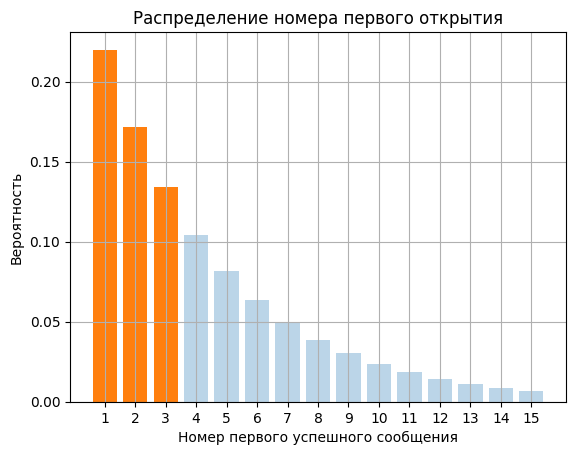

In [ ]:
k_values = np.arange(1, 16)
probabilities = rv.pmf(k_values)
plt.bar(k_values, probabilities, alpha=0.3)

selected_k = np.arange(1, 4)
selected_probabilities = rv.pmf(selected_k)
plt.bar(selected_k, selected_probabilities)

plt.xticks(k_values)
plt.xlabel("Номер первого успешного сообщения")
plt.ylabel("Вероятность")
plt.title("Распределение номера первого открытия")
plt.grid()
plt.show()

# Задача 4. Параболическая плотность

Пусть плотность случайной величины имеет вид

$$
\rho(x)=
\begin{cases}
cx^2, & x\in[0,2],\\
0, & x\notin[0,2].
\end{cases}
$$

Найти
1. $c$
2. Вероятность $\mathbb{P}(0.5\leq \xi\leq 1.5)$
3. Функцию распределения $F_\xi(x)$.

**Решение**





Из условия нормировки

$$
1=\int_{-\infty}^{+\infty}\rho(x)\,dx
=c\int_0^2x^2\,dx
=c\cdot\frac{8}{3},
$$

поэтому

$$
c=\frac{3}{8}.
$$

Вероятность равна

$$
\mathbb{P}(0.5\leq \xi\leq 1.5)
=\int_{0.5}^{1.5}\frac{3}{8}x^2\,dx
=\frac{13}{32}.
$$

Функция распределения:

$$
F_\xi(x)=
\begin{cases}
0, & x<0,\\
\displaystyle\int_0^x\frac{3}{8}t^2\,dt=\frac{x^3}{8}, & 0\leq x\leq2,\\
1, & x>2.
\end{cases}
$$

# Задача 5. Проверка заказов с ошибками

**Познакомимся с новым распределением!**

В продуктовых проверках часто выбирают ограниченную выборку объектов из конечной партии: заказов, транзакций или заявок. Если выбранный объект не возвращается обратно, состав оставшейся партии меняется после каждого шага.

В конце дня в системе находится партия из **500 заказов**. У **35 заказов** есть ошибка в платёжных данных.

Аналитик случайно выбирает **20 разных заказов** для ручной проверки. Один и тот же заказ нельзя выбрать дважды.

Пусть $X$ — число ошибочных заказов среди выбранных 20 заказов.

Нужно:

1. определить распределение $X$
2. найти вероятность не встретить ни одной ошибки
3. найти вероятность встретить хотя бы одну ошибку
4. найти вероятность встретить ровно одну ошибку
5. найти вероятность встретить две или больше ошибок
6. найти минимальный размер проверки, при котором вероятность обнаружить хотя бы одну ошибку не меньше 90%
7. визуализировать распределение

**Решение**

## Пункт 1. Определим распределение

Выбор идёт из конечной партии без возвращения, поэтому число найденных ошибок имеет гипергеометрическое распределение:

$$
X \sim \operatorname{Hypergeom}(N=500, K=35, n=20)
$$

Здесь:

- $N=500$ — размер всей партии
- $K=35$ — число ошибочных заказов
- $n=20$ — размер проверки

Вероятность получить ровно $x$ ошибок равна:

$$
\mathbb{P}(X=x)
=
\frac
{C_{K}^{x} C_{N-K}^{n-x}}
{C_{N}^{n}}
$$

В числителе считаются способы выбрать $x$ ошибочных и $n-x$ обычных заказов, а в знаменателе — все возможные выборки размера $n$.

In [ ]:
from scipy.stats import hypergeom

In [ ]:
batch_size = 500
n_errors = 35
sample_size = 20

rv = hypergeom(
    M=batch_size,
    n=n_errors,
    N=sample_size
)

## Пункт 2. Вероятность нуля ошибок

Нас интересует событие:

$$
X = 0
$$

Функция `pmf()` возвращает вероятность одного конкретного числа найденных ошибок.

In [ ]:
p_zero = rv.pmf(0)

print(
    "Вероятность не найти ошибок:",
    round(p_zero, 4)
)

Вероятность не найти ошибок: 0.2275


Вероятность равна примерно **0.2259**, или **22.59%**.

## Пункт 3. Вероятность хотя бы одной ошибки

Событие «хотя бы одна ошибка» включает много вариантов: одну, две и больше ошибок.

Проще использовать противоположное событие:

$$
\mathbb{P}(X \geq 1)
=
1 - \mathbb{P}(X=0)
$$

In [ ]:
p_at_least_one = 1 - p_zero

print(
    "Вероятность хотя бы одной ошибки:",
    round(p_at_least_one, 4)
)

Вероятность хотя бы одной ошибки: 0.7725


Вероятность равна примерно **0.7741**, или **77.41%**.

## Пункт 4. Вероятность ровно одной ошибки

Нас интересует одно конкретное значение:

$$
X = 1
$$

In [ ]:
p_exactly_one = rv.pmf(1)

print(
    "Вероятность ровно одной ошибки:",
    round(p_exactly_one, 4)
)

Вероятность ровно одной ошибки: 0.357


Вероятность равна примерно **0.3579**, или **35.79%**.

## Пункт 5. Вероятность двух или больше ошибок

Нас интересует событие:

$$
X \geq 2
$$

Функция `sf(1)` считает вероятность значений строго больше 1.

In [ ]:
p_two_or_more = rv.sf(1)

print(
    "Вероятность двух или больше ошибок:",
    round(p_two_or_more, 4)
)

Вероятность двух или больше ошибок: 0.4156


Вероятность равна примерно **0.4162**, или **41.62%**.

## Пункт 6. Минимальный размер проверки для вероятности 90%

Для каждого возможного размера проверки найдём вероятность обнаружить хотя бы одну ошибку.

Остановимся на первом размере, для которого:

$$
\mathbb{P}(X \geq 1) \geq 0.9
$$

In [ ]:
target_probability = 0.9

for check_size in range(1, batch_size + 1):
    current_rv = hypergeom(
        M=batch_size,
        n=n_errors,
        N=check_size
    )

    probability = current_rv.sf(0)

    if probability >= target_probability:
        break

print("Минимальный размер проверки:", check_size)
print("Вероятность обнаружить хотя бы одну ошибку:", round(probability, 4))

Минимальный размер проверки: 31
Вероятность обнаружить хотя бы одну ошибку: 0.902


Нужно проверить минимум **31 заказ**.

При таком размере выборки вероятность обнаружить хотя бы одну ошибку впервые достигает 90%.

## Пункт 7. Визуализация распределения

Покажем вероятности найти от 0 до 7 ошибок в проверке из 20 заказов.

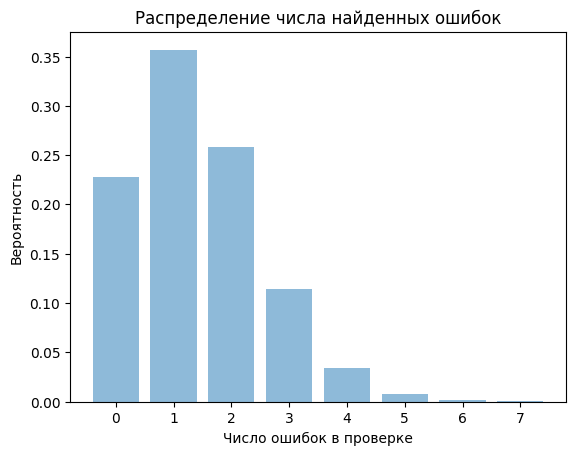

In [ ]:
error_counts = np.arange(0, 8)
probabilities = rv.pmf(error_counts)

plt.bar(error_counts, probabilities, alpha=.5)
plt.xticks(error_counts)
plt.xlabel("Число ошибок в проверке")
plt.ylabel("Вероятность")
plt.title("Распределение числа найденных ошибок")
plt.show()

# Связь гипергеометрического распределения с биномиальным

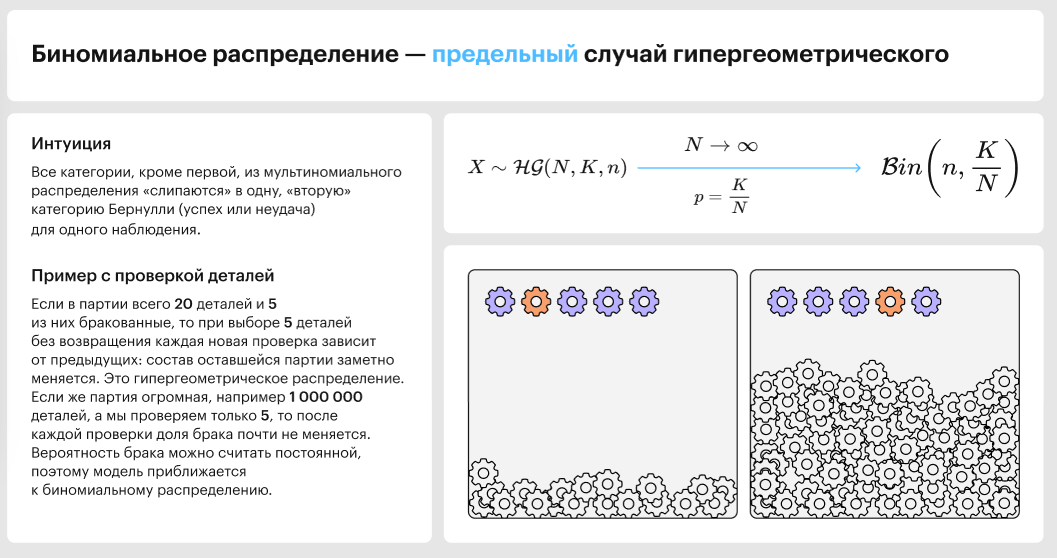

# Познакомимся ещё с двумя распределениями: категориальное и мультиномиальное распределения





### Связь

Категориальное распределение — одно испытание, мультиномиальное — $n$ таких испытаний:

$Cat \rightarrow Multin$

Аналогично: $Bern \rightarrow Bin$.


### Категориальное распределение

**Категориальное распределение** описывает результат одного испытания с $K$ возможными исходами.

Пусть вероятности категорий равны $p_1, p_2, \ldots, p_K$, где $p_1 + \ldots + p_K = 1$.

Тогда $X \sim Cat(p_1,\ldots,p_K)$, а вероятность получить категорию $k$ равна $\mathbb{P}(X=k)=p_k$.

Например, пользователь выбирает один из трёх тарифов с вероятностями $(0.5,\ 0.3,\ 0.2)$. Результат одного пользователя — одна категория.

In [ ]:
plans = ["Basic", "Pro", "Premium"]

Функция *choice* в качестве аргумента берёт вектор вероятностей *p*.

In [ ]:
p = [0.5, 0.3, 0.2]

choice = np.random.choice(
    plans,
    p=p
)

print(choice)

Basic


На $10$ наблюдениях получаем следующий набор результатов.

In [ ]:
choices = np.random.choice(
    plans,
    size=10,
    p=p
)

print(choices)

['Pro' 'Pro' 'Premium' 'Pro' 'Premium' 'Basic' 'Basic' 'Basic' 'Premium'
 'Pro']


Однако на маленьком количестве наблюдений структура исхода может отличаться от теоретического закона распределения. Увеличим количество наблюдением и нарисуем гистограмму.

In [ ]:
choices = np.random.choice(
    plans,
    size=10000,
    p=p
)

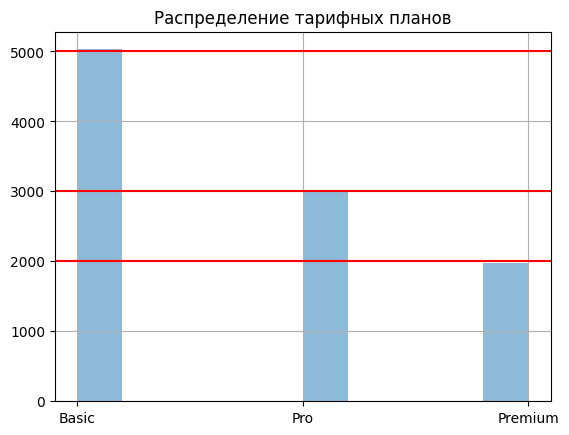

In [ ]:
plt.hist(choices, alpha=.5)
plt.axhline(p[0]*10000, color='red')
plt.axhline(p[1]*10000, color='red')
plt.axhline(p[2]*10000, color='red')
plt.title('Распределение тарифных планов')
plt.grid()
plt.show()

Убираем параметр *p* и получаем равномерное распределение.

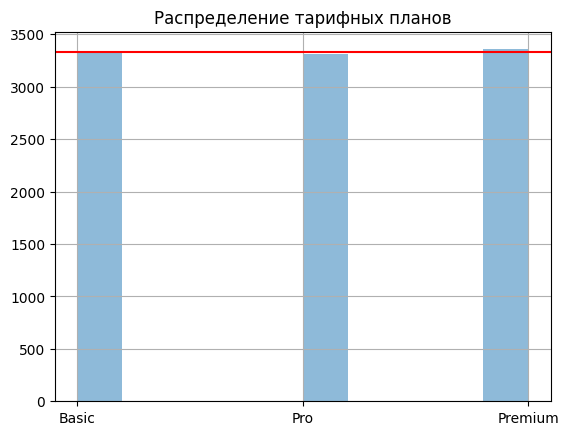

In [ ]:
choices_u = np.random.choice(
    plans,
    size=10000)

plt.hist(choices_u, alpha=.5)
plt.axhline((1/3)*10000, color='red')
plt.title('Распределение тарифных планов')
plt.grid()
plt.show()

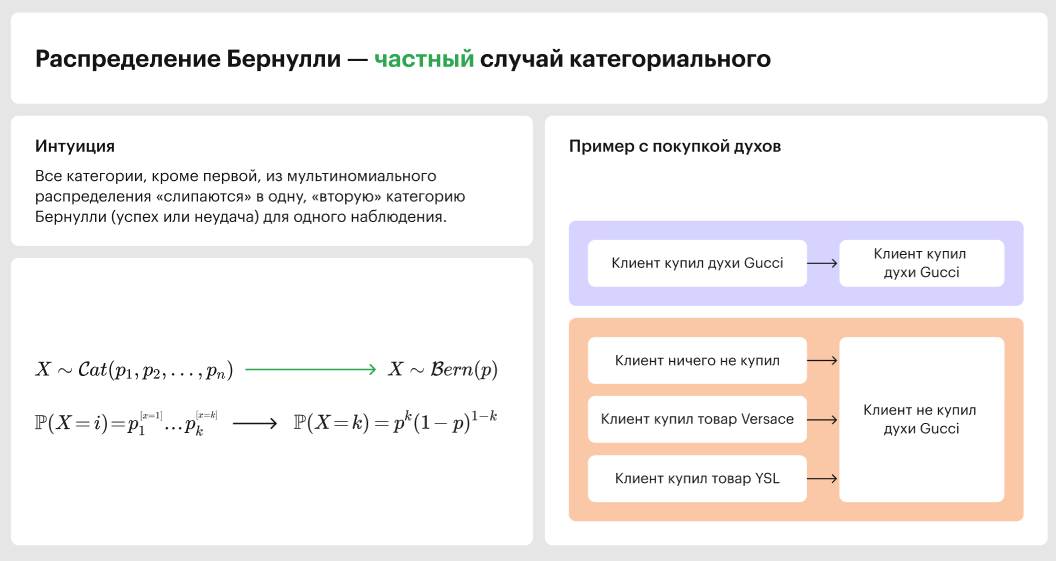

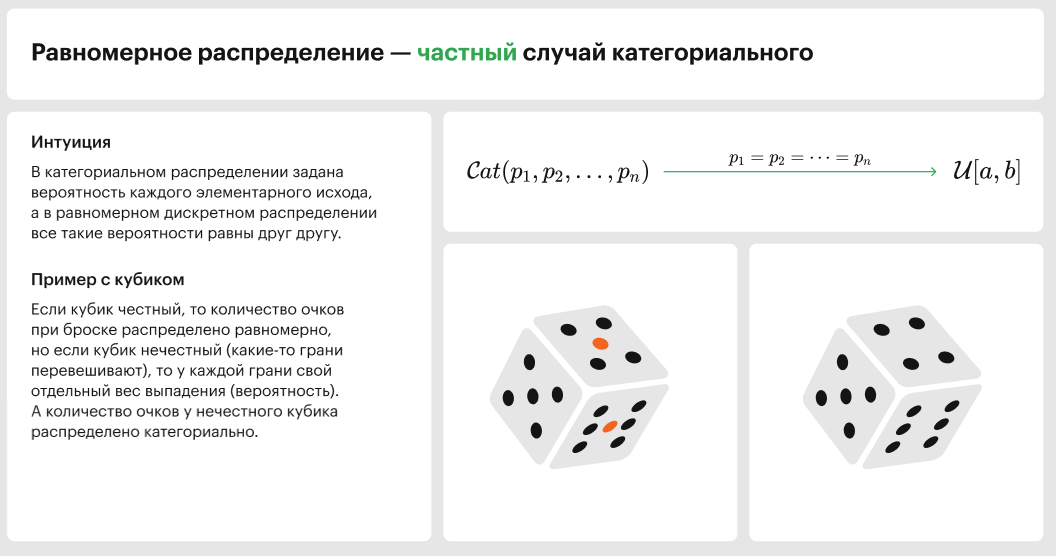

### Мультиномиальное распределение

**Мультиномиальное распределение** описывает результаты $n$ независимых категориальных испытаний.

Пусть $(X_1,\ldots,X_K)$ — количества появлений каждой категории. Тогда $X_1+\ldots+X_K=n$ и

$$
(X_1,\ldots,X_K)\sim Multin (n,p_1,\ldots,p_K)
$$

Вероятность получить конкретные количества $x_1,\ldots,x_K$:

$$
\mathbb{P}(X_1=x_1,\ldots,X_K=x_K)=\frac{n!}{x_1!\cdots x_K!}
\prod_{k=1}^{K}p_k^{x_k}
$$

Например, для $100$ пользователей результат $(48,32,20)$ означает, что первую категорию выбрали 48 пользователей, вторую — 32, третью — 20.

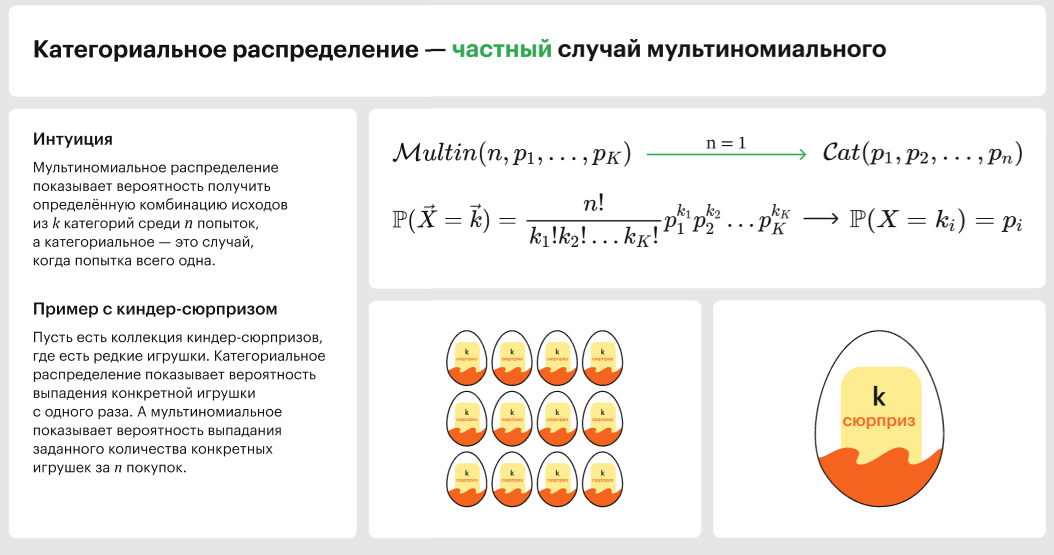

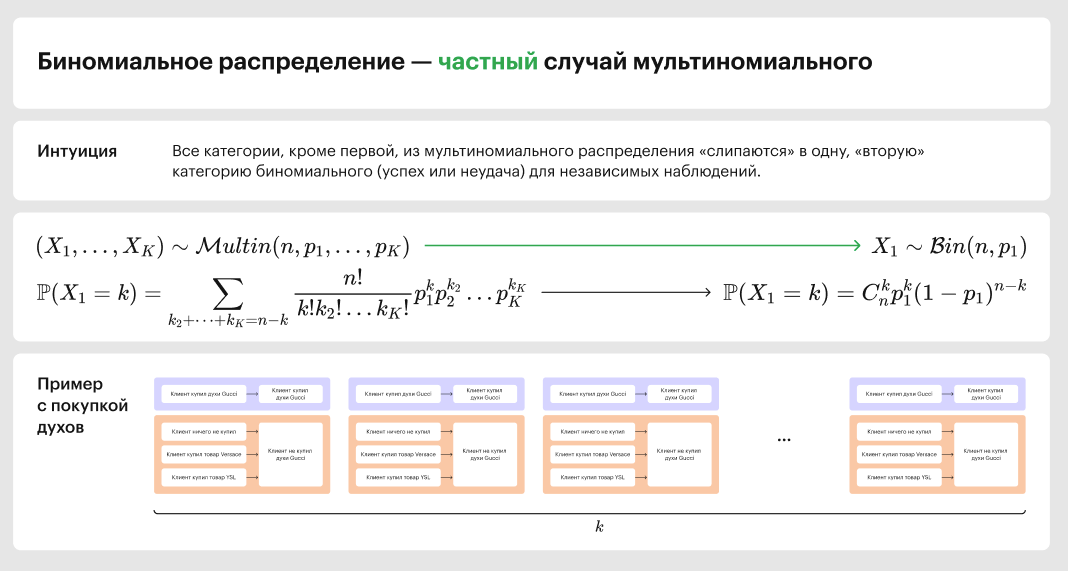

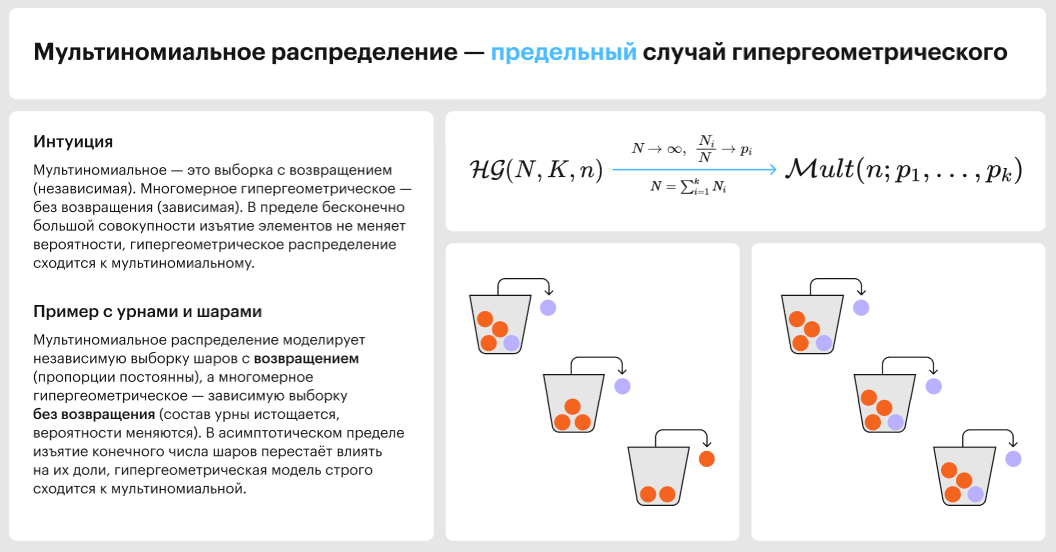

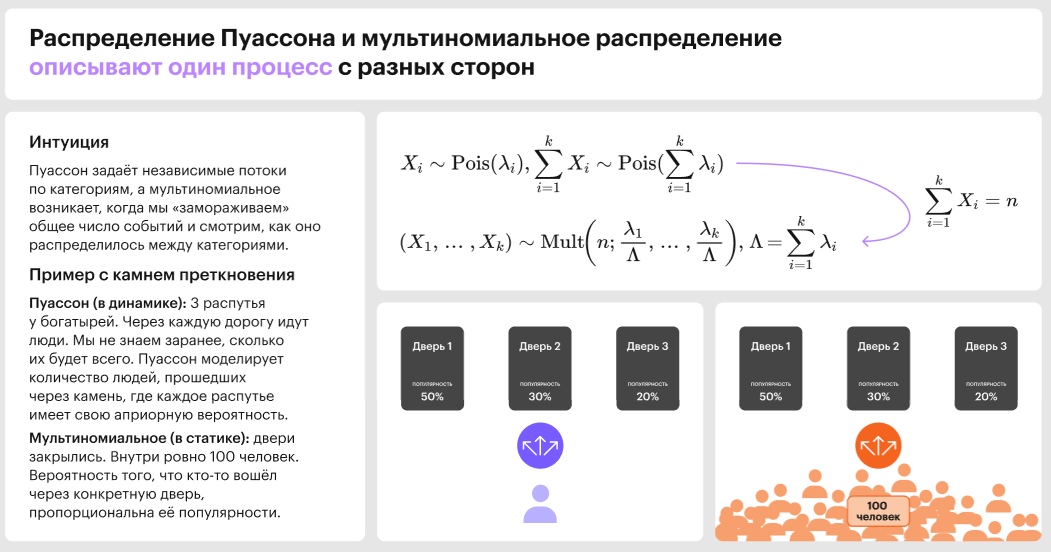

# Посмотрим ещё раз на распределения

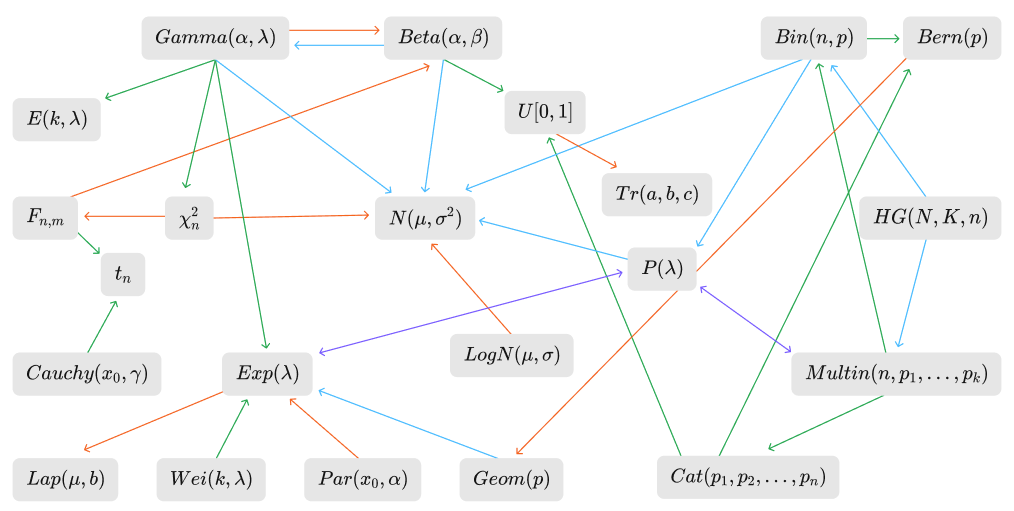

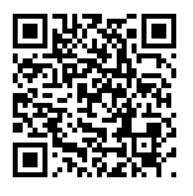